# EDA (Day-1)

### Importing Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading final.csv dataset

In [3]:
df = pd.read_csv('/home/arpitsaxena/Desktop/TSE/Week-6/src/data/processed/final.csv')

### Converting each column to numeric, non-convertible become NaN

In [ ]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

/tmp/ipykernel_30870/1076597268.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


### Printing Categorical and Numerical features

In [5]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numeric columns:", numeric_features)
print("Categorical columns:", categorical_features)

Numeric columns: Index(['Quantity', 'UnitPrice', 'CustomerID'], dtype='object')
Categorical columns: Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object')


### Correlation Matrix

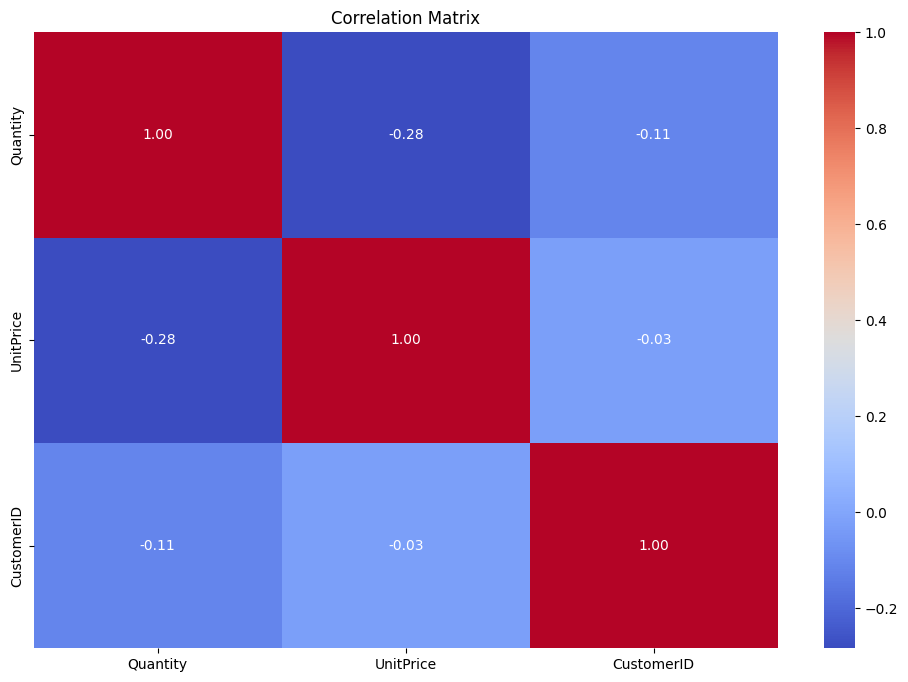

In [6]:
if len(numeric_features) > 1:
    plt.figure(figsize=(12, 8))
    corr_matrix = df[numeric_features].corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()
else:
    print("Not enough numeric columns for correlation matrix.")


### Distribution Graph for Numeric features

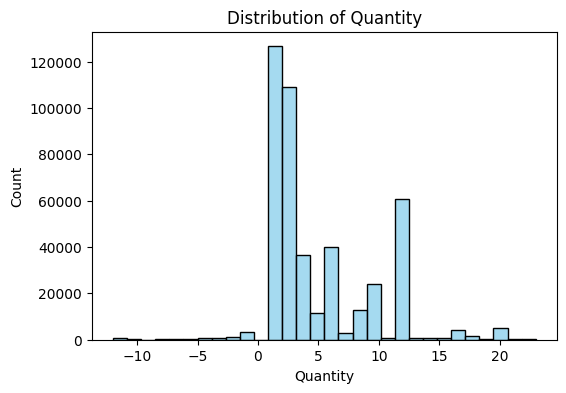

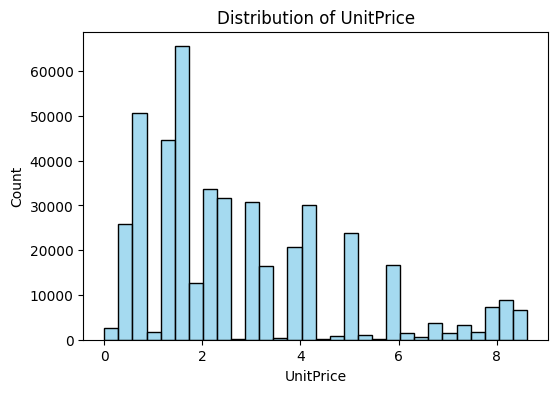

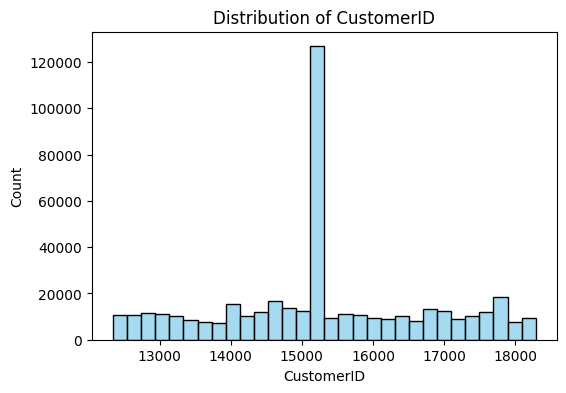

In [7]:
for col in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=False, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()

### Distribution graph for Categorical Features (Top N categories)

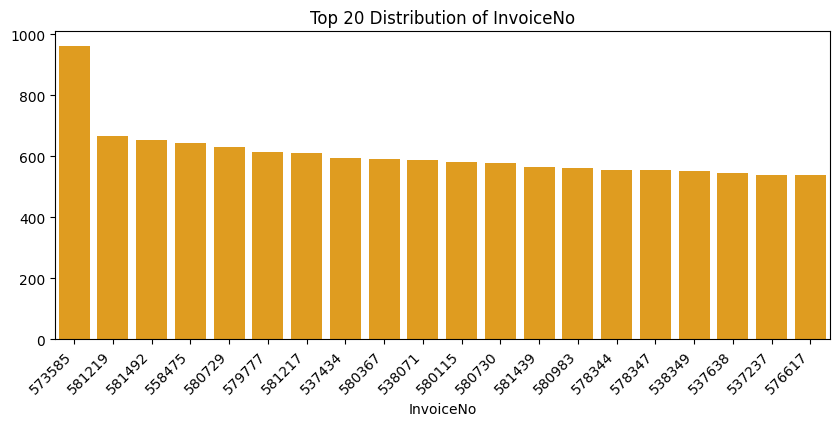

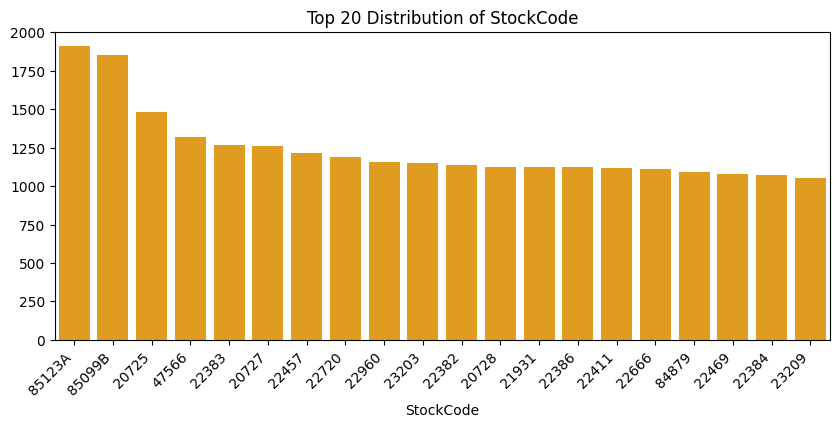

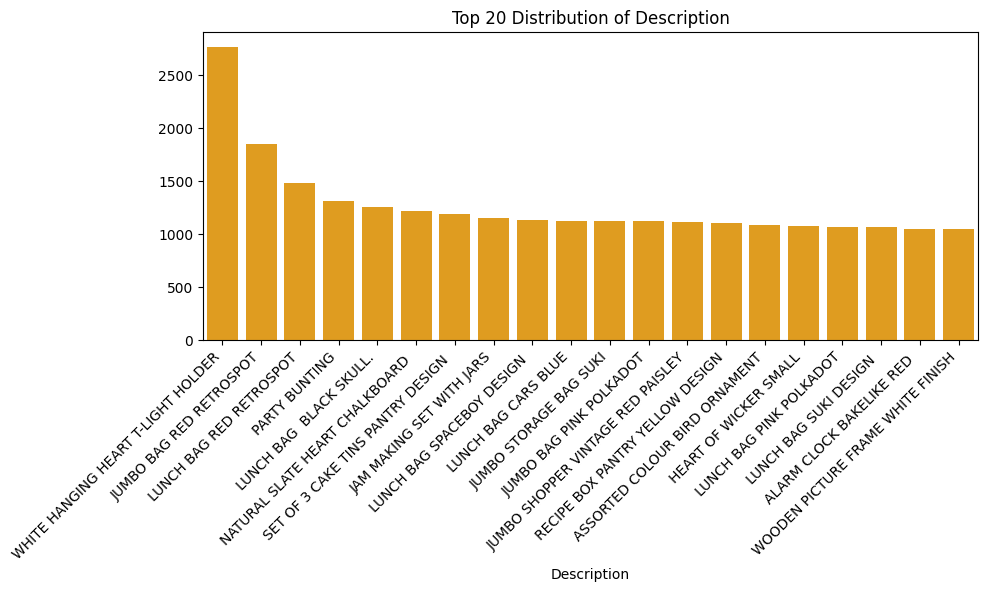

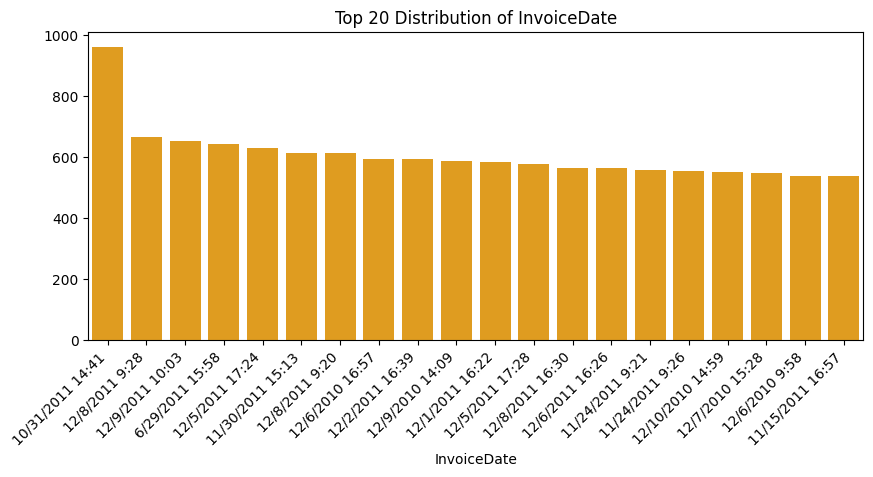

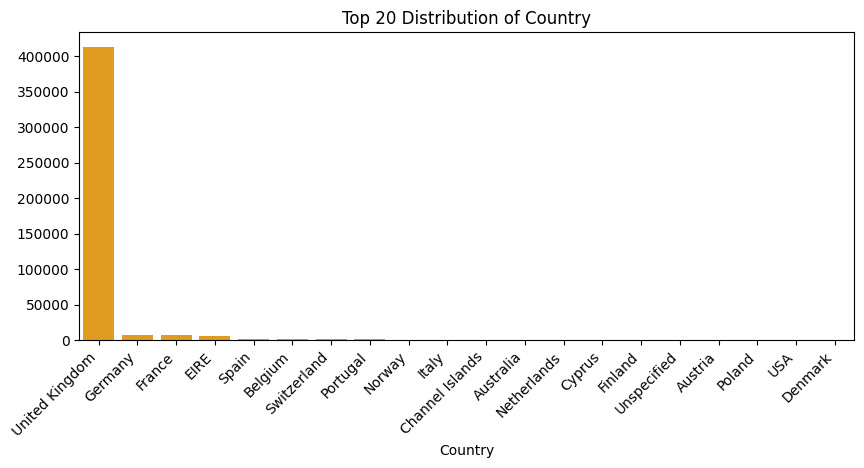

In [ ]:

top_n = 20

for col in categorical_features:
    plt.figure(figsize=(10, 4))
    top_values = df[col].value_counts().nlargest(top_n) 
    sns.barplot(x=top_values.index, y=top_values.values, color='orange')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top {top_n} Distribution of {col}')
    plt.show()


### Target Distribution Graph

/tmp/ipykernel_30870/3432893188.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='Set2')


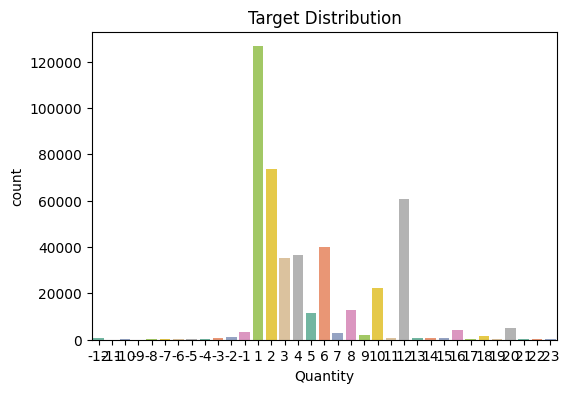

In [9]:
target_col = 'Quantity'
if target_col in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=target_col, data=df, palette='Set2')
    plt.title('Target Distribution')
    plt.show()
else:
    print(f"Column '{target_col}' not found in the dataset.")


### Missing values heatmap (along with missing summary)

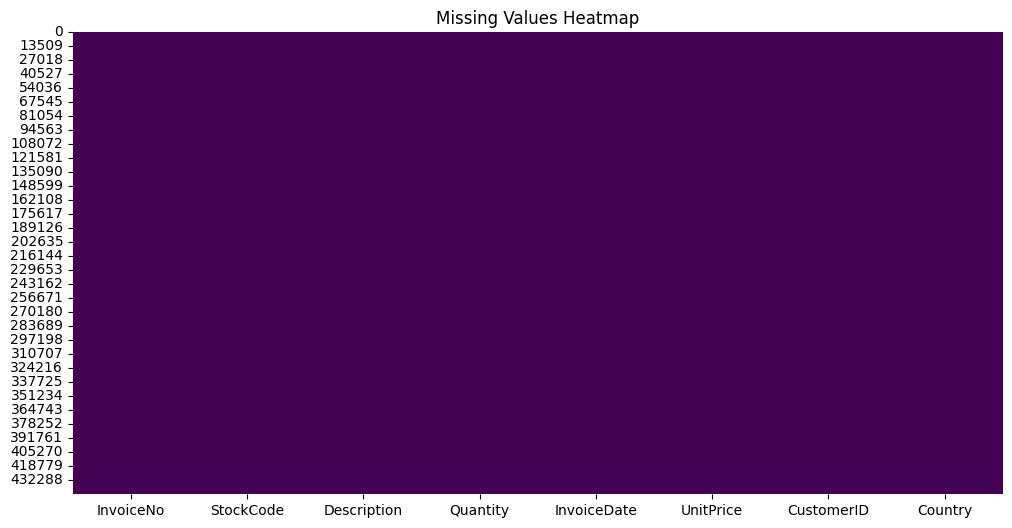

Missing Values per Column:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [10]:

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

missing_summary = df.isnull().sum()
print("Missing Values per Column:")
print(missing_summary)